# Optilat - An optical lattice builder

The OptiLat package is a small convenience package focused on helping the simulation of 1D, 2D and 3D optical lattices. It is designed to integrate with the `bloch_schrodinger` package, and uses `xarray` to handle arbitrary parametric dimensions. In this notebook, we will first review some basic theory behind the computation of optical lattices light fields, then show how to perform these computations automatically using the package. After this, we will briefly show how to compute the AC Stark shift potential created by a simple optical lattice. Additional tutorial notebook show how construct more complicated lattice geometries.

## Optical lattices

A single collimated laser beam can be expressed using a complex notation as $$\mathcal{E}(\bm{r}, t) = \mathcal{E} \mathbf{u} e^{i(\mathbf{k}\cdot\mathbf{r} - \omega t)}$$ where $\mathcal{E}$ is the laser's complex amplitude, $\mathbf{u}$ is the polarization vector, $\omega$ the angular frequency and $\mathbf{k}$ the laser's wave vector. An optical lattice field can then be expressed as 
$$\mathcal{E}_L (\bm{r}, t) = \sum_i \mathcal{E}_i(\bm{r}, t)$$
for a collection of laser beams with fields $\mathcal{E}_i(\bm{r}, t)$. Of course, the field's expression only interests us as far as we can use it to compute the potential it generates for the atoms trapped. In that case, the fast time oscillations of the field are ultimately irrelevant and we are going to drop the time-dependance going on. This introduces however a complication, which is that we will have to keep track of the relative coherence of the laser beams with one another. Before going further, let's build a simple lattice with the `OptiLat` package.

## The "lin-$\theta$-lin" lattice

To show the working principles of the package, we are going to construct a simple 1D lattice yet presenting interesting features, the so-called "lin-$\theta$-lin" lattice. This lattice is made of two coherent, counter propagating laser beams with linear polarizations angled by an angle $\theta$ from one-another. In the case where $\theta = 0$, we recover the simplest optical lattice, consisting in a simple sine standing wave.

The `OptiLat` package introduces two classes, the `Beam` class and the `OptiLat` class, located in the `builder` submodule. The `Beam` class contains all the informations of a single laser beam, while the `OptiLat` class is made of a collection of `Beam` objects and coherence indexes. Let's first build the two laser beams.

In [26]:
from optilat.builder import Beam 
import numpy as np

# Defining some quantities
lamb = 1 # The laser wavelength, here in arbitrary units
k_l = 2*np.pi / lamb # The laser k-vector amplitude

theta = np.pi/8 # The angle between each polarization in radians
E1 = E2 = 1 + 0j # The beams complex amplitudes, here equal, in arbitrary units

# Definign the beams
Beam1 = Beam(
    amplitude=E1,
    wavelength=lamb,
    direction=[1,0,0],
    polar=[np.cos(theta/2), np.sin(theta/2)]
)

Beam2 = Beam(
    amplitude=E2,
    k=k_l,
    direction=[-1,0,0],
    polar=[np.cos(theta/2), np.sin(theta/2)]
)

print(Beam1)

A beam with k-vector: 6.283185307179586, 
direction <xarray.DataArray (component: 3)> Size: 24B
array([1., 0., 0.])
Coordinates:
  * component  (component) int64 24B 0 1 2 
and polarization <xarray.DataArray (Jones: 2)> Size: 16B
array([0.98078528, 0.19509032])
Coordinates:
  * Jones    (Jones) int64 16B 0 1


So what did we do ? First, we defined a few quantities, then, we constructed the Beam objects. A Beam object needs to contain:
1. A complex amplitude.
2. A k-vector $\mathbf{k} = k_L \mathbf{e}_L$ with $k_L$ the norm and $\mathbf{e}_L$ the direction. 
3. A Jones polarization vector $\mathbf{J}$.
Each of these quantities are described by xarray.DataArray objects, which "simply" are numpy.ndarray with annotated dimensions. When we inspect a Beam object using `print`, we get a few of these DataArrays, and we can see that:
+ The direction array (and the k array, not returned here) have a size-3 dimension "component", which represents the x,y and z components of these real-space vectors.
+ The polarization array has a size-2 dimension "Jones", which represents the polarization in the Jones formlism.

The use of xarray objects allows for very powerful broadcasting capabilities, greatly facilitating the creating of parameter-dependant lattices, as we will see shortly.

Finally, we remark that there is 3 methods to specify the k-vector:
1. By giving a wavelength and a direction.
2. By giving a k-vector amplitude and a direction.
3. By giving direcly a k-vector.

Scalar quantities (wavelength or k-vector amplitudes) can be given either as floats or DataArrays with multiple dimensions. Vector quantities (direction or k-vector) can be given either as length-3 lists of floats, length-3 lists of DataArrays, or directly as a single DataArray with a size-3 "component" dimension. The same principles apply to the specification of the polarization vector, using here a size-2 "Jones" dimension in the case of direct definition. Usually, one method makes more sense than the other and is easy to use. Let's demonstrate this by recreating the beams with a parameter dimension for the angle $\theta$.

In [27]:
import xarray as xr

theta = xr.DataArray(np.linspace(0, np.pi, 11), coords={"theta":np.linspace(0, np.pi, 11)})
# One can also use the "create_parameter" function from the `bloch_schrodinger.potential` module to make the creating of this parameter dimension slighly easier.

# Definign the beams
Beam1 = Beam(
    amplitude=E1,
    wavelength=lamb,
    direction=[1,0,0],
    polar=[np.cos(theta/2), np.sin(theta/2)]
)

Beam2 = Beam(
    amplitude=E2,
    k=k_l,
    direction=[-1,0,0],
    polar=[np.cos(theta/2), np.sin(theta/2)]
)

print(Beam1)

A beam with k-vector: 6.283185307179586, 
direction <xarray.DataArray (component: 3)> Size: 24B
array([1., 0., 0.])
Coordinates:
  * component  (component) int64 24B 0 1 2 
and polarization <xarray.DataArray (Jones: 2, theta: 11)> Size: 176B
array([[1.00000000e+00, 9.87688341e-01, 9.51056516e-01, 8.91006524e-01,
        8.09016994e-01, 7.07106781e-01, 5.87785252e-01, 4.53990500e-01,
        3.09016994e-01, 1.56434465e-01, 6.12323400e-17],
       [0.00000000e+00, 1.56434465e-01, 3.09016994e-01, 4.53990500e-01,
        5.87785252e-01, 7.07106781e-01, 8.09016994e-01, 8.91006524e-01,
        9.51056516e-01, 9.87688341e-01, 1.00000000e+00]])
Coordinates:
  * Jones    (Jones) int64 16B 0 1
  * theta    (theta) float64 88B 0.0 0.3142 0.6283 0.9425 ... 2.513 2.827 3.142


Now, we can see that the $\theta$ parameter is encoded into the polarization DataArray by a new "theta" dimension. Now, let's finally construct the actual lattice.

In [28]:
print(Beam1.direction)

<xarray.DataArray (component: 3)> Size: 24B
array([1., 0., 0.])
Coordinates:
  * component  (component) int64 24B 0 1 2


In [29]:
from optilat.builder import OptiLat

lat = OptiLat() # We first create an empty lattice
lat.add_beam(Beam1, index = 0)
lat.add_beam(Beam2, index = 0)

As can be seen, constructing a lattice is very simple. Once one has defined the beams, they simply need to be added to an `OptiLat` object. The only subtelty is this index we have specified. It represents the relatve coherence of each laser beams: **For two beams to be considered coherent by the `OptiLat` class, they must share the same index**. This is very important, as the main function of the OptiLat class, the `compute_fields` functtion, will only direcly add together the beams sharing the same index, as we will see next. In the mean time, one can visualize the placement of teh laser beams and their polarization using the `plot` class method.

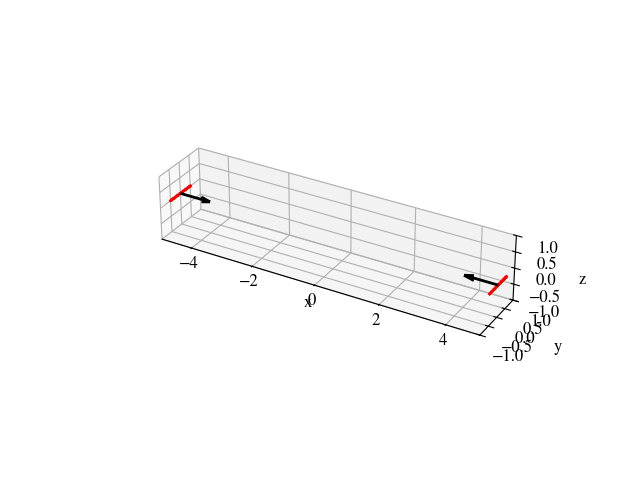

In [30]:
import matplotlib.pyplot as plt
#Activate interactivity
%matplotlib widget

lat.plot(box = [10,2,2])
plt.show()

We indeed have two counter-propagating beams with linear polarization, angled by $\theta$ from one another. It is possible to change the style of the arrows and polarization ellipse using the `laser_style` kwarg, while the `box` kwarg specifies the size of the plotting box.

We are now ready to use the `compute_fields` function of the OptiLat class, which compute the complex field amplitude $$\mathcal{E}(\bm{r}) = \sum_i \mathcal{E}_i \mathbf{u}_i e^{i\mathbf{k_i}\cdot\mathbf{r}}$$ for every coherence index.

In [31]:
x = xr.DataArray(np.linspace(-2,2,300), coords = {"x":np.linspace(-2,2,300)})

E = lat.compute_fields(x = x, y = 0, z = 0) 

print(E.coords)

Coordinates:
  * field      (field) int64 8B 0
  * component  (component) int64 24B 0 1 2
  * theta      (theta) float64 88B 0.0 0.3142 0.6283 ... 2.513 2.827 3.142
  * x          (x) float64 2kB -2.0 -1.987 -1.973 -1.96 ... 1.96 1.973 1.987 2.0


The field is evaluated on a grid that is specified by the 3 DataArrays (or scalar) $x, y, z$. Thanks to the xarray broadcasting rules, non-orthogonal grids can be specified quite easily. Here, we are looking at a 1D lattice, so we can keep y and z equal to 0. The `compute_fields` function outputs a DataArray with dimensions for each of the grid dimensions, parameter dimensions, and the field dimension (here of size 1).

## Atomic potential

For a two-level atom, the AC Stark shift can be expressed as:
$$\delta E = -\frac{1}{2} \text{Re}(\alpha) |\mathcal{E}(\mathbf{r})|^2$$
With $\alpha$ the complex polarizability of the transition. We are not going to get into the details of it's determination here, nor are we going to go further into the computation of the polarization-dependant vector polarizabilty. Here, we are going to set arbitrarily the value of $\alpha$, independantly of any physical consideration, and just look how the potential $V(\hat{\mathbf{r}}) = -\frac{1}{2} \text{Re}(\alpha) |\mathcal{E}(\hat{\mathbf{r}})|^2$ looks like. To plot it, we are going to use the interactive function `plot_cuts`from the `bloch_schrodinger`package.

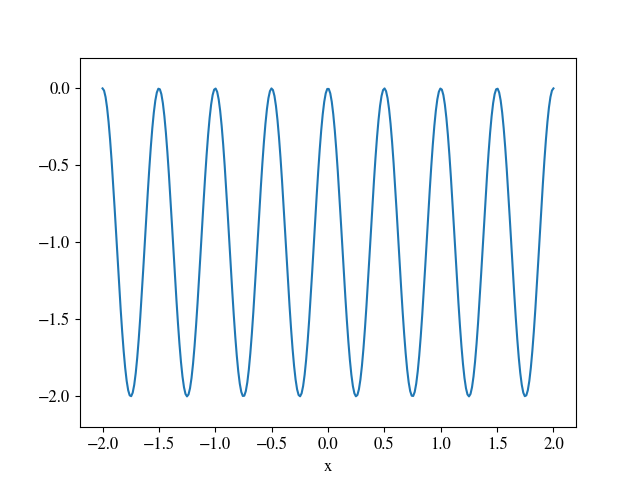

In [32]:
from bloch_schrodinger.plotting import plot_cuts

alpha = 1
V = -alpha * (abs(E)**2).sum("component") / 2

plot_cuts(V, dim = "x", groupby=[], ymin = -2.2, ymax=0.2)
plt.show()

We recover exactly the expected behavior: When $\theta = 0$, the beams are fully interfering, leading to a sine potential of amplitude $\alpha \mathcal{E} / 2 = 2$, whereas for $\theta = \pi/2$, the beams are cross-polarized, reducing the contrast of the lattice to 0.

Don't hesitate to play around with the parameters of this lattice, or go and take a look at more complex geometries in the other notebooks of the documentation, where multiple coherence index are needed, or where the polarization of the light plays a crucial role.